# DEG20 Downstream Experiment

多条件版 scPRAM-style DEG20 downstream 实验。这个 notebook 直接消费现有 full-gene `pkl`，不重新训练模型。

核心定义：
- 真实 DEG20：直接使用 `DE_idx / DE_name`，即我们当前 TriShift 口径的 `top20_degs_non_dropout`。
- 预测 DEG20：从 `Pred_full / Ctrl_full` 生成。多行预测优先走 Scanpy 排名；单行预测自动退化为 effect-size 排名。
- 主指标：`common_degs_at_20`、`jaccard_at_20`、`precision_at_20`、`recall_at_20`，以及限定在 truth DEG20 上的 `scpram_r2_degs_mean_mean / scpram_r2_degs_var_mean / scpram_wasserstein_degs_sum`。

默认推荐：
- `pred_deg_mode = "adaptive"`
- `pred_deg_mode = "ttest_non_dropout"` 可按和真实 `DEG20` 更接近的口径生成预测 `DEG20`
- `pred_deg_mode = "effect_size_non_dropout"` 可按 `|mu_pred - mu_ctrl| + non-dropout + 去掉 perturb gene + top20` 生成预测 `DEG20`
- `enrichment_mode = "export_only"`
- `variant_tag = "nearest"` 仅在 `model_name="trishift"` 且目标产物是 `trishift_*_nearest.pkl` 时需要设置


In [1]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.deg20_experiment as deg20_experiment
importlib.reload(deg20_experiment)

run_deg20_experiment = deg20_experiment.run_deg20_experiment
load_condition_payload = deg20_experiment.load_condition_payload
summarize_condition_payload = deg20_experiment.summarize_condition_payload
build_mean_var_scatter = deg20_experiment.build_mean_var_scatter

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
repo_root


WindowsPath('e:/CODE/trishift')

## Parameters

设置一个模型、一个数据集，以及要分析的 split。


In [ ]:
dataset = "adamson"
model_name = "trishift"  # trishift | gears | genepert | scouter
split_ids = [1, 2, 3, 4, 5]
result_dir = None  # 可手动覆盖结果目录
out_root = None  # 可手动覆盖 notebook 输出目录
variant_tag = "nearest"  # trishift ??: nearest / random / None
focus_conditions = []  # 例如 ["ATP5B+ctrl", "BHLHE40+ctrl"]
pred_deg_mode = "ttest_non_dropout"  # adaptive | scanpy | effect_size | effect_size_non_dropout | ttest_non_dropout
enrichment_mode = "export_only"  # export_only | run_if_available | disabled
enrichment_library = "Reactome_2022"
remove_perturbed_genes = True

run_kwargs = dict(
    dataset=dataset,
    model_name=model_name,
    split_ids=split_ids,
    result_dir=result_dir,
    out_root=out_root,
    variant_tag=variant_tag,
    focus_conditions=focus_conditions or None,
    pred_deg_mode=pred_deg_mode,
    enrichment_mode=enrichment_mode,
    enrichment_library=enrichment_library,
    remove_perturbed_genes=remove_perturbed_genes,
)
run_kwargs


{'dataset': 'adamson',
 'model_name': 'trishift',
 'split_ids': [1, 2, 3, 4, 5],
 'result_dir': None,
 'out_root': None,
 'variant_tag': 'nearest',
 'focus_conditions': None,
 'pred_deg_mode': 'effect_size_non_dropout',
 'enrichment_mode': 'export_only',
 'enrichment_library': 'Reactome_2022',
 'remove_perturbed_genes': True}

In [3]:
result = run_deg20_experiment(**run_kwargs)
print(f"out_dir: {result.out_dir}")
display(result.dataset_summary_df)
display(result.split_summary_df)
display(result.per_condition_df.head(20))


out_dir: E:\CODE\trishift\artifacts\results\adamson\deg20_downstream_20260314_010458


,model_name,dataset,n_splits,common_degs_at_20_mean,common_degs_at_20_median,jaccard_at_20_mean,jaccard_at_20_median,precision_at_20_mean,precision_at_20_median,recall_at_20_mean,recall_at_20_median,truth_deg_count_mean,truth_deg_count_median,pred_deg_count_mean,pred_deg_count_median,scpram_r2_degs_mean_mean_mean,scpram_r2_degs_mean_mean_median,scpram_r2_degs_var_mean_mean,scpram_r2_degs_var_mean_median,scpram_wasserstein_degs_sum_mean,scpram_wasserstein_degs_sum_median
0,trishift,adamson,5,8.176471,8.2,0.271709,0.266452,0.408824,0.41,0.42774,0.431579,19.117647,19.0,20.0,20.0,0.950418,0.984744,0.544736,0.472953,4.759664,3.585789


,model_name,dataset,split_id,n_conditions,n_scanpy_rank,n_effect_size_fallback,common_degs_at_20_mean,common_degs_at_20_median,jaccard_at_20_mean,jaccard_at_20_median,precision_at_20_mean,precision_at_20_median,recall_at_20_mean,recall_at_20_median,truth_deg_count_mean,truth_deg_count_median,pred_deg_count_mean,pred_deg_count_median,scpram_r2_degs_mean_mean_mean,scpram_r2_degs_mean_mean_median,scpram_r2_degs_var_mean_mean,scpram_r2_degs_var_mean_median,scpram_wasserstein_degs_sum_mean,scpram_wasserstein_degs_sum_median
0,trishift,adamson,1,17,0,0,9.588235,9.0,0.334773,0.300000,0.479412,0.45,0.502941,0.473684,19.058824,19.0,20.0,20.0,0.966466,0.979493,0.251295,0.115777,5.238339,4.659949
1,trishift,adamson,2,17,0,0,8.058824,8.0,0.264283,0.258065,0.402941,0.40,0.421362,0.421053,19.117647,19.0,20.0,20.0,0.955503,0.981666,0.311699,0.077670,5.276302,3.807629
2,trishift,adamson,3,17,0,0,7.823529,8.0,0.257643,0.258065,0.391176,0.40,0.409288,0.421053,19.117647,19.0,20.0,20.0,0.941643,0.987005,0.447193,0.410266,5.382714,4.517090
3,trishift,adamson,4,17,0,0,7.529412,8.0,0.241869,0.258065,0.376471,0.40,0.394427,0.421053,19.117647,19.0,20.0,20.0,0.946462,0.988187,0.866636,0.904749,3.685588,2.527216
4,trishift,adamson,5,17,0,0,7.882353,8.0,0.259976,0.258065,0.394118,0.40,0.410681,0.421053,19.176471,19.0,20.0,20.0,0.942014,0.987371,0.846857,0.856304,4.215380,2.417059


,model_name,dataset,split_id,condition,focus_key,pkl_path,pred_deg_mode_used,common_degs_at_20,jaccard_at_20,precision_at_20,recall_at_20,truth_deg_count,pred_deg_count,scpram_r2_degs_mean_mean,scpram_r2_degs_var_mean,scpram_wasserstein_degs_sum
0,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,5,0.147059,0.25,0.263158,19,20,0.989867,0.014910,3.655438
1,trishift,adamson,1,BHLHE40+ctrl,1:BHLHE40+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,9,0.300000,0.45,0.473684,19,20,0.934031,0.006314,11.634383
2,trishift,adamson,1,CARS+ctrl,1:CARS+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,11,0.392857,0.55,0.578947,19,20,0.899418,0.747620,9.799662
3,trishift,adamson,1,CCND3+ctrl,1:CCND3+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,10,0.344828,0.50,0.526316,19,20,0.949302,0.406759,5.471101
4,trishift,adamson,1,COPB1+ctrl,1:COPB1+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,11,0.379310,0.55,0.550000,20,20,0.979493,0.634368,5.075341
5,trishift,adamson,1,DERL2+ctrl,1:DERL2+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,8,0.258065,0.40,0.421053,19,20,0.980695,0.211875,3.829683
6,trishift,adamson,1,HARS+ctrl,1:HARS+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,9,0.300000,0.45,0.473684,19,20,0.977063,0.747427,7.095632
7,trishift,adamson,1,HYOU1+ctrl,1:HYOU1+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,9,0.300000,0.45,0.473684,19,20,0.988473,0.089426,4.659949
8,trishift,adamson,1,MANF+ctrl,1:MANF+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,9,0.300000,0.45,0.473684,19,20,0.997980,0.233660,3.353666
9,trishift,adamson,1,MRPL39+ctrl,1:MRPL39+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,effect_size_non_dropout,10,0.344828,0.50,0.526316,19,20,0.954567,0.055748,4.017556


## Metric Distributions

这里先看每个 condition 的 overlap / regression / Wasserstein 指标分布。


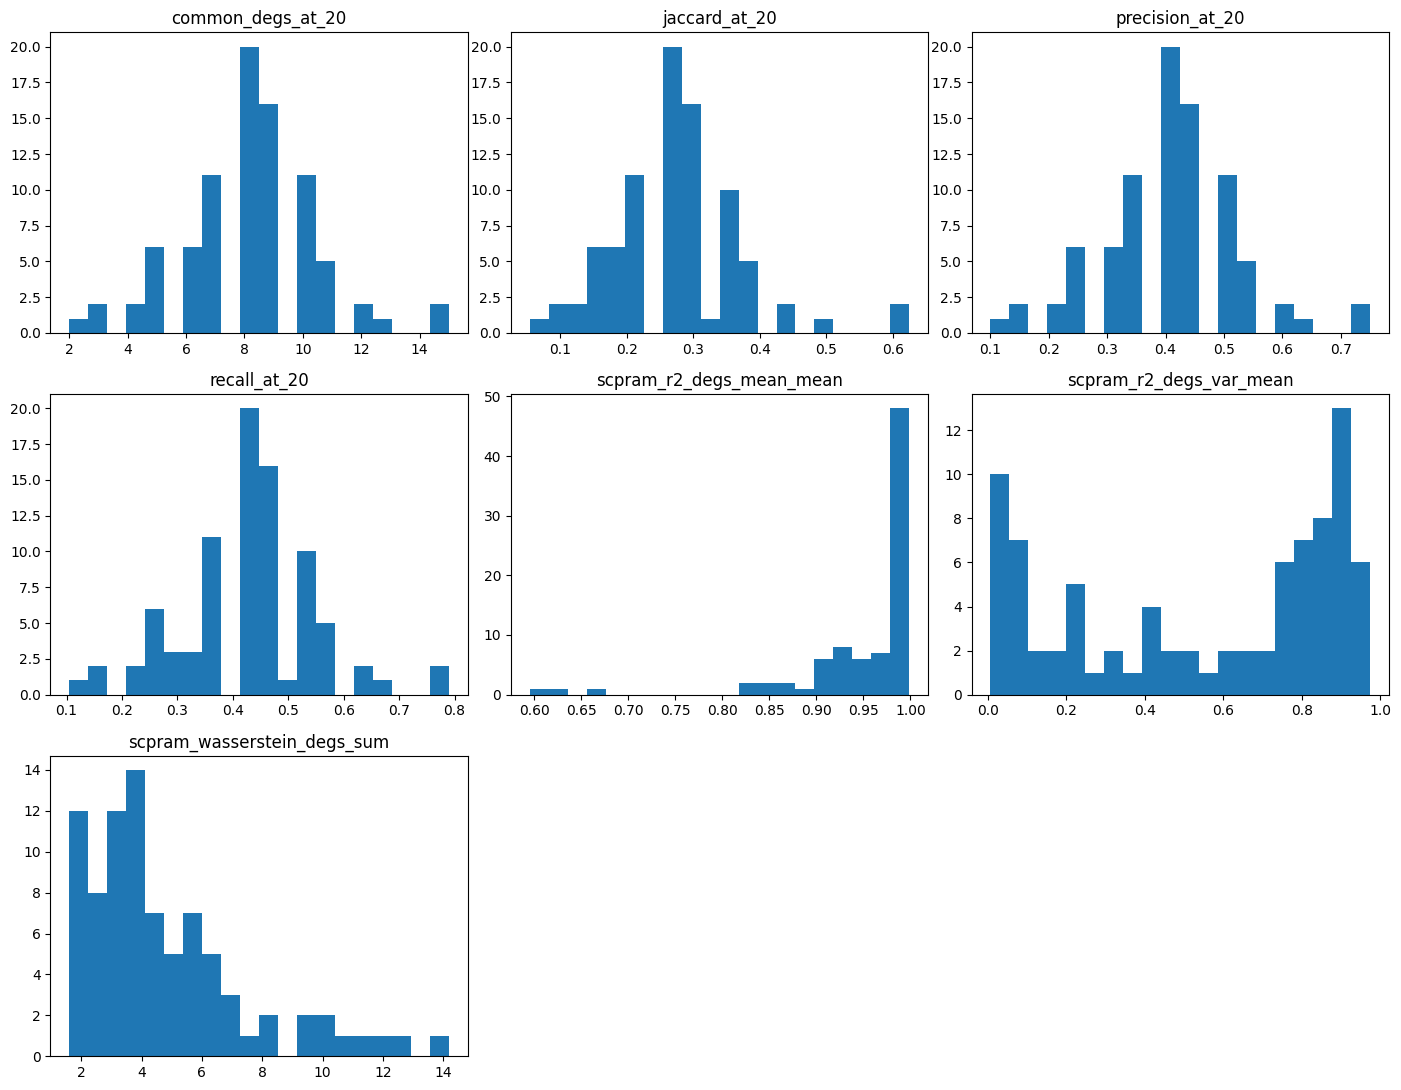

,count,mean,std,min,25%,50%,75%,max
common_degs_at_20,85.0,8.176471,2.351172,2.000000,7.000000,8.000000,9.000000,15.000000
jaccard_at_20,85.0,0.271709,0.100224,0.054054,0.218750,0.258065,0.300000,0.625000
precision_at_20,85.0,0.408824,0.117559,0.100000,0.350000,0.400000,0.450000,0.750000
recall_at_20,85.0,0.427740,0.123125,0.105263,0.368421,0.421053,0.473684,0.789474
scpram_r2_degs_mean_mean,85.0,0.950418,0.076624,0.595490,0.925418,0.983779,0.994460,0.998767
scpram_r2_degs_var_mean,85.0,0.544736,0.343180,0.006314,0.207348,0.672500,0.866935,0.973753
scpram_wasserstein_degs_sum,85.0,4.759664,2.762331,1.608357,3.035756,3.829683,5.882111,14.185671


In [4]:
metric_cols = [
    "common_degs_at_20",
    "jaccard_at_20",
    "precision_at_20",
    "recall_at_20",
    "scpram_r2_degs_mean_mean",
    "scpram_r2_degs_var_mean",
    "scpram_wasserstein_degs_sum",
]
plot_df = result.per_condition_df[metric_cols].apply(pd.to_numeric, errors="coerce")
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for ax, col in zip(axes, metric_cols):
    vals = plot_df[col].dropna()
    ax.hist(vals, bins=min(20, max(5, len(vals))))
    ax.set_title(col)
for ax in axes[len(metric_cols):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

display(result.per_condition_df[metric_cols].describe().T)


## Representative Conditions

默认会自动挑 overlap 最好 / 中位 / 最差的 3 个 condition；如果你在参数里填了 `focus_conditions`，这里就按你指定的 condition 展示。


In [5]:
rep_cols = [
    "split_id",
    "condition",
    "pred_deg_mode_used",
    "common_degs_at_20",
    "jaccard_at_20",
    "scpram_r2_degs_mean_mean",
    "scpram_r2_degs_var_mean",
    "scpram_wasserstein_degs_sum",
]
display(result.representative_df[rep_cols])


,split_id,condition,pred_deg_mode_used,common_degs_at_20,jaccard_at_20,scpram_r2_degs_mean_mean,scpram_r2_degs_var_mean,scpram_wasserstein_degs_sum
0,1,SRP72+ctrl,effect_size_non_dropout,15,0.625000,0.996447,0.074267,3.175936
1,4,DDRGK1+ctrl,effect_size_non_dropout,8,0.258065,0.994820,0.920165,1.625414
2,3,DERL2+ctrl,effect_size_non_dropout,2,0.054054,0.973458,0.010194,4.410539



=== split 1 | SRP72+ctrl ===


,truth_deg20,pred_deg20,common_deg20
0,SNHG12,RPS21,RPS21
1,RPS8,RPS29,RPS29
2,RPS27,VIM,RPS12
3,MAT2A,RPS12,MAT2A
4,RPL37A,MAT2A,RPL37A
5,RPL32,RPL37A,RPS28
6,RPL14,RPS28,RPL37
7,RPL37,RPL37,RPL28
8,RPS12,RPL28,RPL32
9,CITED2,RPL32,RPL13A


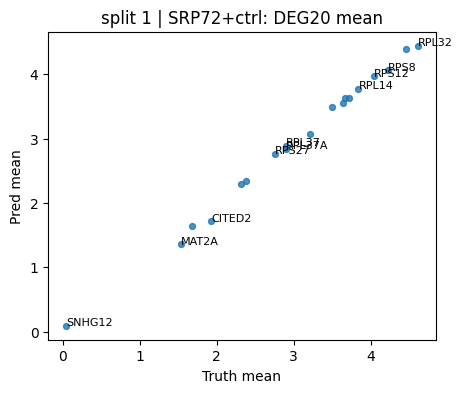

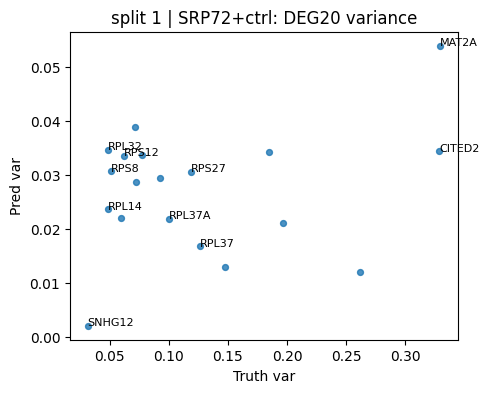


=== split 4 | DDRGK1+ctrl ===


,truth_deg20,pred_deg20,common_deg20
0,RPS8,VIM,RPS29
1,RPS27,RPS29,MAT2A
2,MAT2A,DDIT4,RPS21
3,RPL37A,MAT2A,RPS28
4,RPL32,RPS21,APOE
5,RPL14,RPS28,RPL37
6,RPL37,APOE,RPS12
7,RPS12,SH3BGRL3,RPL37A
8,RPL12,RPL37,RPL28
9,CD63,RPS12,RPS27


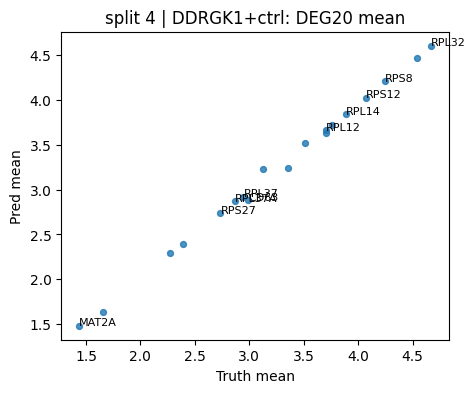

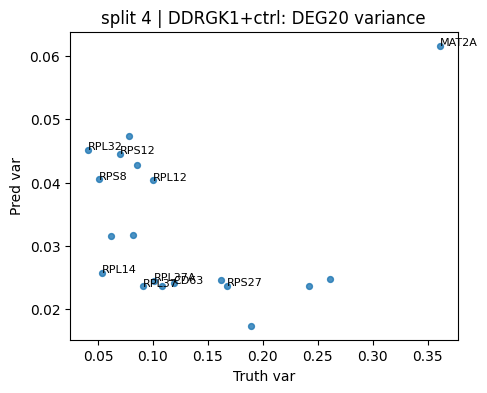


=== split 3 | DERL2+ctrl ===


,truth_deg20,pred_deg20,common_deg20
0,RPS8,HBZ,RPS29
1,RPS27,SDF2L1,RPS21
2,RPL37A,FCER1G,NaN
3,RPL32,TIMP1,NaN
4,RPL14,MANF,NaN
5,RPL37,RPS29,NaN
6,RPS10,HIST1H1E,NaN
7,RPS12,SH3BGRL3,NaN
8,RPL12,VIM,NaN
9,RPS29,IFITM2,NaN


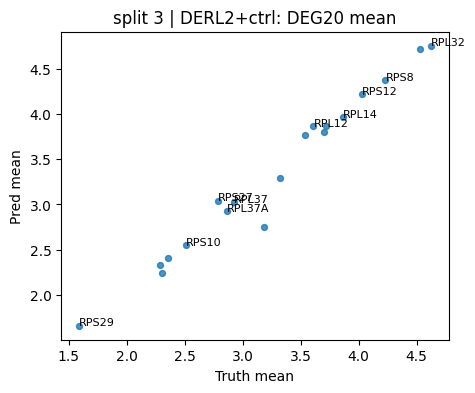

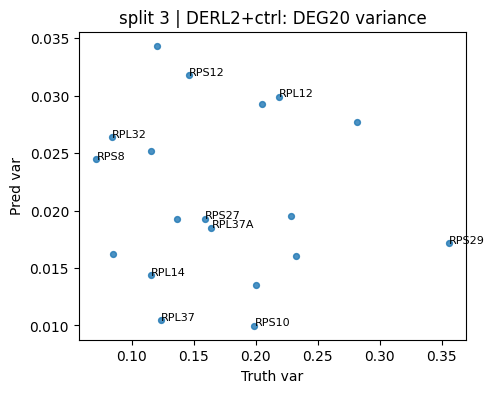

In [6]:
for row in result.representative_df.to_dict(orient="records"):
    split_id = int(row["split_id"])
    condition = str(row["condition"])
    payload_item = load_condition_payload(
        model_name=model_name,
        dataset=dataset,
        split_id=split_id,
        condition=condition,
        result_dir=result_dir,
        variant_tag=variant_tag,
    )
    detail = summarize_condition_payload(
        payload_item=payload_item,
        condition=condition,
        pred_deg_mode=pred_deg_mode,
        remove_perturbed_genes=remove_perturbed_genes,
    )
    print(f"\n=== split {split_id} | {condition} ===")
    display(
        pd.DataFrame(
            {
                "truth_deg20": pd.Series(detail["truth_deg20"]),
                "pred_deg20": pd.Series(detail["pred_deg20"]),
                "common_deg20": pd.Series(detail["common_deg20"]),
            }
        )
    )
    fig_mean, fig_var = build_mean_var_scatter(
        payload_item=payload_item,
        truth_deg_idx=detail["truth_deg_idx"],
        title_prefix=f"split {split_id} | {condition}",
    )
    plt.show(fig_mean)
    plt.show(fig_var)
    plt.close(fig_mean)
    plt.close(fig_var)


## Exported Gene Lists

主流程默认总会导出三类 gene list：`truth_deg20` / `pred_deg20` / `common_deg20`。


In [7]:
display(result.gene_lists_df.head(30))
print(result.out_dir / "deg_gene_lists_long.csv")


,model_name,dataset,split_id,condition,focus_key,list_type,rank,gene,pred_deg_mode_used
0,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,1,RPS29,effect_size_non_dropout
1,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,2,RPS28,effect_size_non_dropout
2,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,3,RPS21,effect_size_non_dropout
3,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,4,RPL37A,effect_size_non_dropout
4,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,5,MS4A3,effect_size_non_dropout
5,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,pred_deg20,1,HBZ,effect_size_non_dropout
6,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,pred_deg20,2,SH3BGRL3,effect_size_non_dropout
7,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,pred_deg20,3,HBA1,effect_size_non_dropout
8,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,pred_deg20,4,DDIT4,effect_size_non_dropout
9,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,pred_deg20,5,RPS29,effect_size_non_dropout


E:\CODE\trishift\artifacts\results\adamson\deg20_downstream_20260314_010458\deg_gene_lists_long.csv


## Optional Enrichment

当 `enrichment_mode="run_if_available"` 且环境里有 `gseapy` 时，这里会显示 enrichment 结果；否则 notebook 只保留 gene list 导出。


In [8]:
if result.enrichment_df.empty:
    print("No enrichment results. This is expected when enrichment_mode='export_only' or gseapy is unavailable.")
else:
    display(result.enrichment_df.head(30))


No enrichment results. This is expected when enrichment_mode='export_only' or gseapy is unavailable.


## Notes

- `common_degs_at_20` 和 `jaccard_at_20` 更直接回答“预测 DEG20 和 truth DEG20 重合多少”。
- `scpram_r2_degs_mean_mean` / `scpram_r2_degs_var_mean` 更接近 scPRAM 论文里 DEG mean/variance regression 的思想。
- `scpram_wasserstein_degs_sum` 越低越好，表示预测和真实在 DEG20 子空间上的分布差更小。
